In [2]:
import numpy as np
import pandas as pd

import scipy.stats as stats 

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

scipy.stats// used for QQ plot
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
// these are two diffrent algos

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','2urvived'])

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [5]:
df.head()

,Age,Fare,2urvived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [6]:
df.isnull().sum()

Age         0
Fare        0
2urvived    0
dtype: int64

there are no missing values in any column as sum of null values is 0

so we dont have need of [7] column

In [7]:
X = df.iloc[:,0:2]
y = df.iloc[:,2]

X, y values extract

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

/var/folders/4d/sgmmqjqj59l8_w6n4qgy17_00000gn/T/ipykernel_2571/2888751792.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


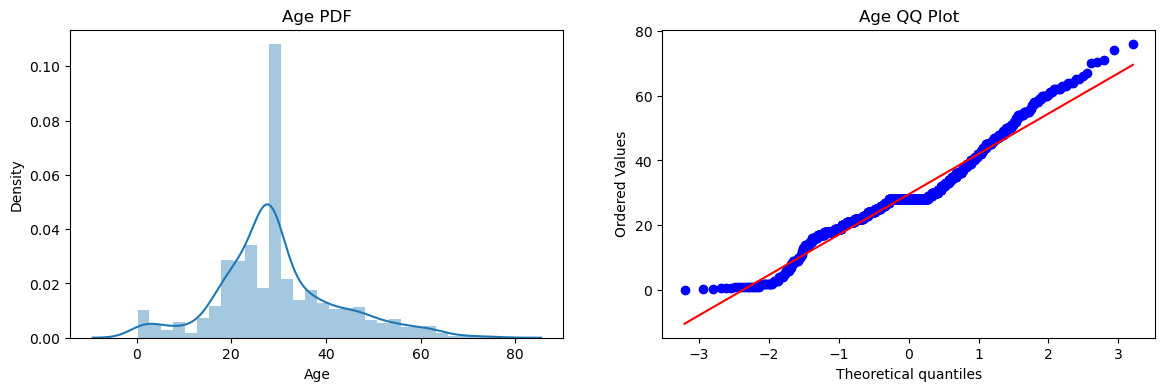

In [9]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

/var/folders/4d/sgmmqjqj59l8_w6n4qgy17_00000gn/T/ipykernel_2571/474975069.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


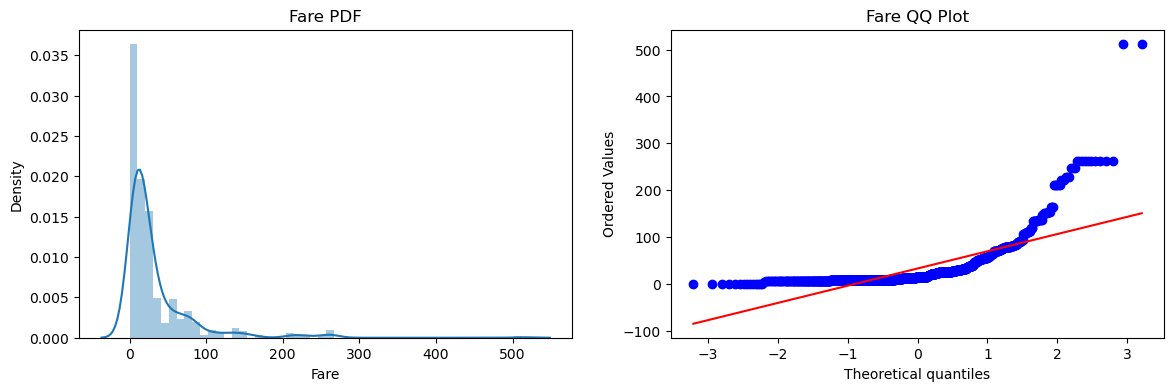

In [10]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

121 means 1 row, 2 columns created and next 1 tells that we are now working on 1st part, similarly for 122, RESULT shows fare is right skewed, so we must apply log tranform to it

Now, we r creating two objects for two algos

In [12]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

creating two objects for LogisticRegression and DecisionTree

In [13]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test,y_pred1))

Accuracy LR 0.7022900763358778
Accuracy DT 0.648854961832061


#Applying function transformation on both columns: Age and Fare

In [14]:
trf = FunctionTransformer(func=np.log1p)

Here, log1p used so that denominator is never 0

In [15]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [16]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test)
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test,y_pred1))

Accuracy LR 0.7061068702290076
Accuracy DT 0.7213740458015268


#Before transformation: Logistic Regression performed better than Decision Tree.
After transformation: Decision Tree performed better than Logistic Regression.Therefore, for this dataset, function transformation was more beneficial for the Decision Tree than for Logistic Regression.

Now, cross validating to check results

In [17]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.6791015854374634
DT 0.6844333529066354


#Even on cross validating, we got same result that is accuracy of Decision tree is better than Logistic Regression

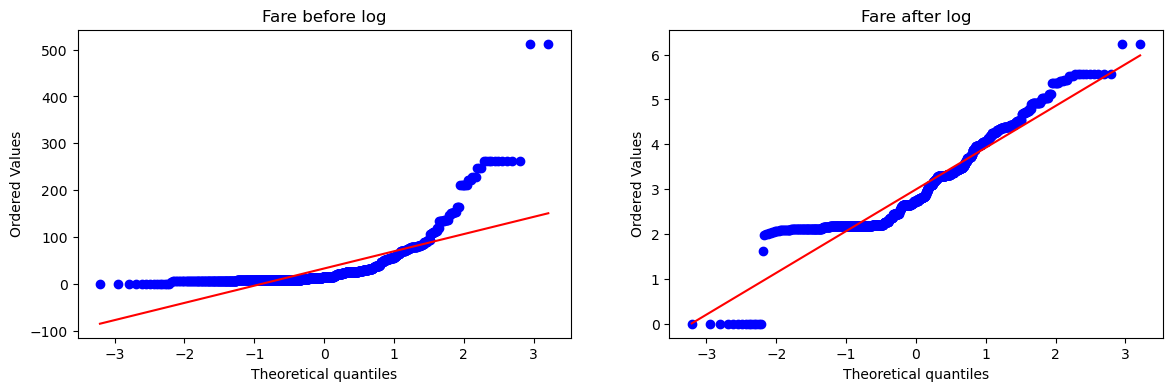

In [18]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare before log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare after log')

plt.show()

NOW, APPLYING TRANSFORMATION ONLY ON FARE COLUMN AND NOT ON AGE

In [40]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

Remainder passthrough means age column will reamin as it is

In [41]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.7099236641221374
Accuracy DT 0.6335877862595419


#Now, when only fare transformation is done, accuracy improved from 67 to 70 in Logistic Regression while decreased in Decision tree

Again applying cross value score

In [42]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))




LR 0.7341103934233705
DT 0.6775631238990016


Nutshell, obs1:) in the given data age was already normally distributed and Fare was right skewed; On Fare, we applied log transform and then again applied Logistic Regression, result improved
obs2:)We also applied another algorithm that was decision tree; its result was same before and after transformation ; Decision Tree is independent of data distribution

In [29]:
def apply_transform(transform):
    X = df[['Age', 'Fare']]
    y = df['2urvived']

    trf = ColumnTransformer(
        [('transform', FunctionTransformer(transform), ['Fare'])],
        remainder='passthrough'
    )

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare before transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare after transform')  

    plt.show()
    

this function will tell accuracy, provide QQ plot before and after transformation

Accuracy 0.73873165002936


<Figure size 1400x400 with 0 Axes>

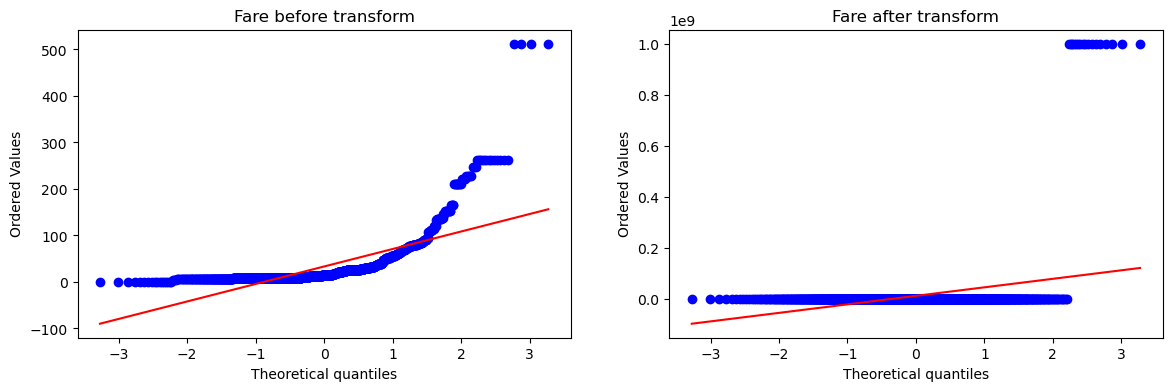

In [32]:
apply_transform(lambda x: 1/(x+0.000000001))

#Applied reciprocal with condition that denominator cant be zero

Accuracy 0.7364298297122724


<Figure size 1400x400 with 0 Axes>

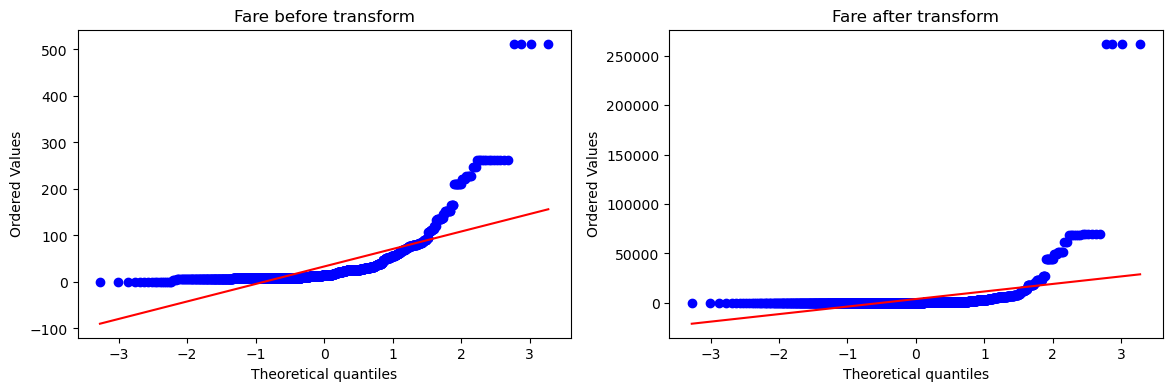

In [33]:
apply_transform(lambda x: (x**2))

#Applied square

Accuracy 0.7310745742806811


<Figure size 1400x400 with 0 Axes>

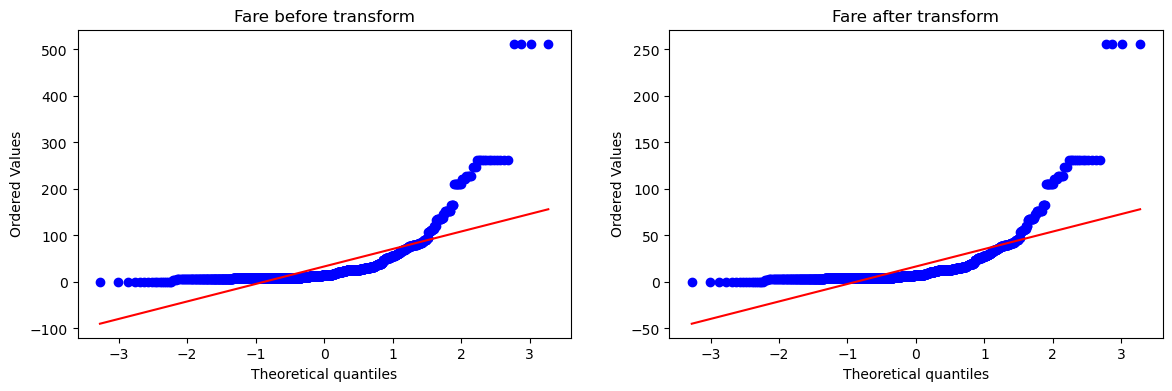

In [34]:
apply_transform(lambda x:(x**1/2))

#Applied square root

Accuracy 0.73873165002936


<Figure size 1400x400 with 0 Axes>

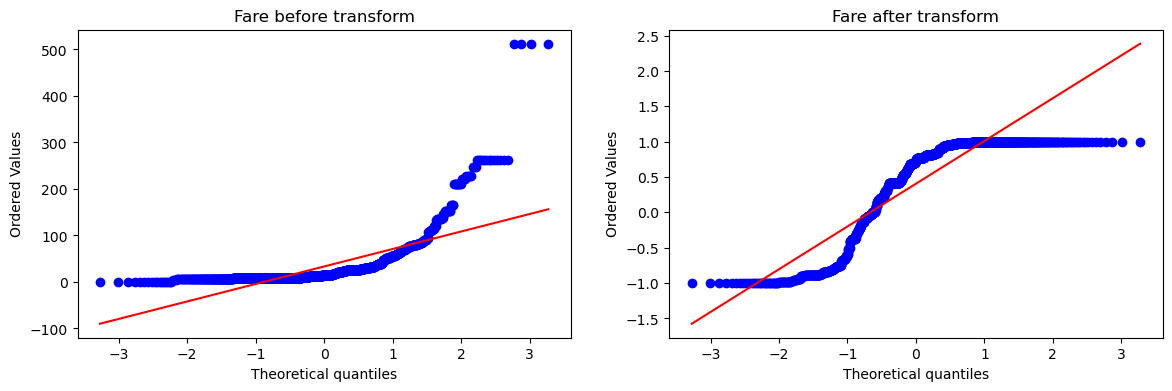

In [35]:
apply_transform(np.sin)